### 1. Problem Understanding
Below is a more detailed, step-by-step explanation on how to tackle the Spam Detection problem using the ML workflow as a guide:
- **Objective:**  
  Build a classifier that correctly labels the remaining 1500 emails as either spam or non-spam.

- **Task Type:**  
  This is a binary classification task with two classes: spam (coded as 2) and non-spam (coded as 1).

- **Error Costs:**  
  The cost of misclassification is asymmetric:  
  - Misclassifying a non-spam email as spam incurs a cost of **5**.  
  - Misclassifying a spam email as non-spam incurs a cost of **1**.  
  This implies you must optimize your model based on a cost-sensitive loss function rather than simple accuracy.

- **Key Questions:**  
  - What is the distribution of spam versus non-spam in the labeled dataset?  
  - How will you incorporate the cost sensitivity into the model training (via class weights or custom loss functions)?

### 2. Data Understanding

- **Data Composition:**  
  - Total emails: 4601  
  - Labeled emails: 3101 (with known class labels)  
  - Unlabeled emails: 1500 (to be predicted)

- **Features (57 total):**  
  - **48 word frequency features:**  
    Each feature measures the percentage of words in an email that match a specific word (e.g., "business", "address", "internet").  
  - **6 special character frequency features:**  
    These include features like `charSemicolon`, `charRoundbracket`, `charSquarebracket`, `charExclamation`, `charDollar`, and `charHash`.
  - **3 capitalization-based features:**  
    - `capitalAve`: The average length of uninterrupted sequences of capital letters.  
    - `capitalLong`: The length of the longest uninterrupted sequence of capital letters.  
    - `capitalTotal`: The total length (sum) of all uninterrupted capital letter sequences.

- **Exploratory Questions:**  
  - How do the features differ between spam and non-spam emails?
  - Are there any missing or unusual values in the dataset?
  - Is there any redundancy or multicollinearity among the features?

### 3. Data Preprocessing

- **Data Cleaning:**  
  - **Missing Values:** Identify if any features have missing data. If present, consider imputing missing values or removing the affected rows/columns.  
  - **Outlier Detection:** Look for extreme values that might skew your model, particularly in the capitalization-based features.

- **Feature Scaling and Transformation:**  
  - **Normalization/Standardization:** Since many features are percentages or counts, scaling might be necessary (e.g., using StandardScaler or MinMaxScaler) to ensure that all features contribute equally during model training.
  - **Encoding:**  
    - Ensure that categorical variables (if any) are properly encoded.
    - In this case, the labels are numerical but ensure consistency (e.g., spam = 2 and non-spam = 1).

- **Feature Engineering (if needed):**  
  - Combine or transform features if you suspect some features could work better together.
  - Use domain knowledge (e.g., high capital letter usage might be a strong indicator of spam).

- **Data Splitting:**  
  - Split the labeled data (3101 emails) into training and validation sets.  
  - Ensure that the split respects the class distribution (use stratified sampling if necessary).

# EDA

In [3]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
weights_df = pd.read_csv('weights-matrix.csv')

# Check the shape and first few rows of each dataset
print("Train Data Shape:", train_df.shape)
print("Train Data Head:")
train_df.head()

Train Data Shape: (3101, 58)
Train Data Head:


,response,make,address,all,num3d,our,over,remove,internet,order,...,conference,charSemicolon,charRoundbracket,charSquarebracket,charExclamation,charDollar,charHash,capitalAve,capitalLong,capitalTotal
0,1,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0,...,0.0,0.000,0.000,0.0,0.925,0.000,0.000,1.833,6,11
1,2,0.0,0.0,0.00,0.0,2.94,0.00,0.0,0.00,0.0,...,0.0,0.335,0.335,0.0,0.671,0.000,0.000,4.000,12,28
2,2,0.0,0.0,1.15,0.0,0.38,0.38,0.0,0.00,0.0,...,0.0,0.000,0.196,0.0,0.261,0.000,0.000,5.666,56,272
3,2,0.1,0.3,0.40,0.0,0.20,0.90,0.2,0.50,0.8,...,0.0,0.000,0.175,0.0,0.307,0.175,0.014,6.937,669,1214
4,1,0.1,0.0,0.00,0.0,0.00,0.10,0.0,0.52,0.0,...,0.0,0.027,0.138,0.0,0.041,0.041,0.000,2.321,31,469


In [82]:
# print("Test Data Shape:", test_df.shape)
# print("Test Data Head:")
# test_df.head()

In [83]:
# print("Weights Matrix Shape:", weights_df.shape)
# print("Weights Matrix Head:") 
# weights_df.head()

In [84]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3101 entries, 0 to 3100
Data columns (total 58 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   response           3101 non-null   int64  
 1   make               3101 non-null   float64
 2   address            3101 non-null   float64
 3   all                3101 non-null   float64
 4   num3d              3101 non-null   float64
 5   our                3101 non-null   float64
 6   over               3101 non-null   float64
 7   remove             3101 non-null   float64
 8   internet           3101 non-null   float64
 9   order              3101 non-null   float64
 10  mail               3101 non-null   float64
 11  receive            3101 non-null   float64
 12  will               3101 non-null   float64
 13  people             3101 non-null   float64
 14  report             3101 non-null   float64
 15  addresses          3101 non-null   float64
 16  free               3101 

In [85]:
# Print summary statistics
train_df.iloc[:,:15].describe()

,response,make,address,all,num3d,our,over,remove,internet,order,mail,receive,will,people,report
count,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000,3101.000000
mean,1.391809,0.099536,0.232012,0.282367,0.065085,0.307814,0.099436,0.113180,0.101593,0.091283,0.239636,0.057459,0.537578,0.098523,0.054166
std,0.488233,0.295143,1.396425,0.514573,1.444585,0.656423,0.293695,0.399119,0.389125,0.289005,0.674758,0.188501,0.867055,0.318666,0.343450
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.150000,0.000000,0.790000,0.000000,0.000000
max,2.000000,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,2.060000,9.670000,5.550000,10.000000


In [86]:
from matplotlib.pyplot import subplots
# fig, ax = subplots(ncols=4, figsize=(15, 5))
# filtered_train_df.boxplot("make",by="response",ax=ax[0]);
# filtered_train_df.boxplot("address",by="response",ax=ax[1]);
# filtered_train_df.boxplot("all",by="response",ax=ax[2]);
# filtered_train_df.boxplot("num3d",by="response",ax=ax[3]);


In [87]:
# filtered_train_df['make'].unique()

#### Data cleaning

In [4]:
filtered_train_df = train_df.copy()

In [5]:
# Count the number of duplicate rows
duplicates = filtered_train_df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 214


In [6]:
# Remove duplicate rows and update the DataFrame in place
filtered_train_df.drop_duplicates(inplace=True)

# Verify that duplicates have been removed
duplicates_after = filtered_train_df.duplicated().sum()
print("Number of duplicate rows after removal:", duplicates_after)

Number of duplicate rows after removal: 0


In [7]:
# check for duplicates colums
col = filtered_train_df.columns
duplicate_features = []
for i in range(len(col)):
    for j in range(i+1, len(col)):
        if filtered_train_df[col[i]].equals(filtered_train_df[col[j]]):
            duplicate_features.append((col[i],col[j]))
duplicate_features # [] -> there is no duplicate features

[]

In [8]:
# check for constant features
constant_features = [col for col in filtered_train_df.columns if filtered_train_df[col].nunique() == 1]
constant_features # [] there is no constant_features

[]

In [9]:
# check for near-zero variance
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder

# Identify Near-Zero Variance Features
#    You can define a threshold for variance below which a feature is considered near-zero variance.
#    The choice of threshold depends on your data and domain knowledge.
threshold = 0.01  # Example threshold
selector = VarianceThreshold(threshold=threshold)

# Before using VarianceThreshold, ensure all columns are numeric.
# If you have categorical columns, either encode them or exclude them from this step.
# Create the encoder and fit-transform the categorical column (reshaped as a 2D array)
# Suppose 'df' is your DataFrame and 'categorical_column' is the column you want to encode.
# df_encoded = pd.get_dummies(train_df, columns=['categorical_column'], drop_first=True)
# df = pd.concat([df.drop('categorical_column', axis=1), encoded_df], axis=1)

# it seems like they are all numerical features

selector.fit(filtered_train_df)
mask = selector.get_support()  # True for columns that meet the threshold
nzv_features = filtered_train_df.columns[~mask]  # columns that do NOT meet the threshold

In [10]:
print(nzv_features)
filtered_train_df.drop(nzv_features,axis=1,inplace=True)
test_df.drop(nzv_features,axis=1,inplace=True)
filtered_train_df

Index(['table', 'charSquarebracket'], dtype='object')


,response,make,address,all,num3d,our,over,remove,internet,order,...,edu,conference,charSemicolon,charRoundbracket,charExclamation,charDollar,charHash,capitalAve,capitalLong,capitalTotal
0,1,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.000,0.000,0.925,0.000,0.000,1.833,6,11
1,2,0.00,0.00,0.00,0.0,2.94,0.00,0.0,0.00,0.00,...,0.0,0.0,0.335,0.335,0.671,0.000,0.000,4.000,12,28
2,2,0.00,0.00,1.15,0.0,0.38,0.38,0.0,0.00,0.00,...,0.0,0.0,0.000,0.196,0.261,0.000,0.000,5.666,56,272
3,2,0.10,0.30,0.40,0.0,0.20,0.90,0.2,0.50,0.80,...,0.0,0.0,0.000,0.175,0.307,0.175,0.014,6.937,669,1214
4,1,0.10,0.00,0.00,0.0,0.00,0.10,0.0,0.52,0.00,...,0.0,0.0,0.027,0.138,0.041,0.041,0.000,2.321,31,469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3095,2,0.13,0.13,0.26,0.0,0.26,0.26,0.0,0.13,0.39,...,0.0,0.0,0.000,0.137,0.000,0.068,0.000,2.736,30,468
3096,2,0.00,0.00,0.00,0.0,1.35,0.45,0.0,0.00,0.00,...,0.0,0.0,0.000,0.138,0.138,0.000,0.000,5.809,46,122
3097,1,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.000,0.000,0.000,0.000,0.000,1.718,11,55
3098,2,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,...,0.0,0.0,0.147,0.000,0.294,0.147,0.000,2.333,11,63


In [11]:
# Compute lower and upper bounds for each column
lower = filtered_train_df.quantile(0.05)
upper = filtered_train_df.quantile(0.95)

# Clip all columns using the computed bounds
filtered_train_df = filtered_train_df.clip(lower, upper, axis=1)

t_lower = test_df.quantile(0.05)
t_upper = test_df.quantile(0.95)
test_df = test_df.clip(t_lower, t_upper, axis=1)

In [96]:
## Skewness ...

In [ ]:
# filtered_train_df.to_csv('filtered_train.csv')
# test_df.to_csv('filtered_test.csv')

# Lasso regression

Lasso and Ridge are both regularization techniques that help reduce overfitting by penalizing large coefficients, but they are suited to different situations:

- **Lasso (L1 Regularization):**
  - **Feature Selection:** Lasso tends to set some coefficients exactly to zero, which effectively performs feature selection. This is especially useful when you suspect that only a few features are truly relevant.
  - **High-Dimensional Data:** When you have a large number of features (many of which may be irrelevant), Lasso can help identify and retain only the most important predictors.
  - **Sparse Models:** If you want a more interpretable model with a reduced set of features, Lasso is a strong candidate.
  - **Linear Relationships:** Lasso works best when the underlying relationships are approximately linear.

- **Ridge (L2 Regularization):**
  - **Multicollinearity:** Ridge is particularly effective when predictors are highly correlated. It shrinks coefficients continuously without setting them exactly to zero, which helps to distribute the effects among correlated variables.
  - **When All Features Contribute:** If you believe that most or all features have some predictive power, Ridge helps by reducing the impact of noise while retaining all predictors.
  - **Stability:** Ridge regression tends to produce more stable estimates in the presence of multicollinearity compared to Lasso.
  - **Non-Sparse Solutions:** When you want to keep all features in the model (or nearly all of them) and you’re more concerned with reducing variance than with simplifying the model, Ridge is a good choice.

In practice, it's also common to use **Elastic Net**, which combines both L1 and L2 penalties. This allows you to balance between feature selection (via Lasso) and handling multicollinearity (via Ridge), depending on your data and the specific problem at hand.

Elastic Net is a versatile regularization technique that combines the benefits of both Lasso (L1) and Ridge (L2) regression. It not only performs feature selection (by shrinking some coefficients to zero, as Lasso does) but also handles multicollinearity (like Ridge). Below is a detailed explanation of how to use Elastic Net in Python, along with a comprehensive code example and commentary on each step.

---

### What Elastic Net Does

- **Regularization:**  
  Elastic Net adds both L1 and L2 penalties to the loss function. This means the cost function is modified as follows:

  \[
  \text{Loss} = \text{RSS} + \alpha \left( \lambda \sum_{j=1}^{p} | \beta_j | + (1-\lambda) \sum_{j=1}^{p} \beta_j^2 \right)
  \]

  Here,  
  - **RSS** is the residual sum of squares.
  - **$\alpha$** controls the overall strength of regularization.
  - **$lambda$** (or `l1_ratio` in scikit-learn) controls the balance between L1 and L2 penalties:
    - `l1_ratio = 1` is equivalent to Lasso.
    - `l1_ratio = 0` is equivalent to Ridge.
    - Values between 0 and 1 give you a mix of both.

- **Why Use Elastic Net:**  
  - **Feature Selection:** It can shrink some coefficients exactly to zero (like Lasso), effectively selecting features.
  - **Handling Multicollinearity:** It stabilizes the model by distributing the weight among correlated predictors (like Ridge).
  - **Flexibility:** By tuning both \(\alpha\) and `l1_ratio`, you can find the best combination for your dataset.

---

### Using Elastic Net in Python with ElasticNetCV

scikit-learn provides a handy class called `ElasticNetCV` which automatically performs cross-validation to select the best values for both `alpha` and `l1_ratio`.

Here is a detailed code example:

```python
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ----------------------------
# 1. Load the Data
# ----------------------------
# For demonstration, assume a regression problem. Replace 'target' with your continuous target.
df = pd.read_csv('/mnt/data/train.csv')

# Let's assume our dataset is for a regression problem.
# If your target variable is not named 'target', change this accordingly.
# If you're working with a classification task, Elastic Net might be applied within logistic regression.
X = df.drop('target', axis=1)  # Replace 'target' with your target variable
y = df['target']              # Replace 'target' with your target variable

# ----------------------------
# 2. Split the Data
# ----------------------------
# Splitting data into training and testing sets to evaluate the model performance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------
# 3. Initialize and Fit ElasticNetCV
# ----------------------------
# ElasticNetCV will automatically search for the best alpha (regularization strength)
# and l1_ratio (mixing parameter). Here, we provide a grid of possible l1_ratio values.
elastic_net_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0],  # 1.0 is pure Lasso, values closer to 0 are more Ridge-like.
    cv=5,               # 5-fold cross-validation
    random_state=42,    # For reproducibility
    max_iter=10000,     # Increased iterations to ensure convergence
    n_alphas=100,       # Number of alpha values to try
)

# Fit the model using the training data
elastic_net_cv.fit(X_train, y_train)

# ----------------------------
# 4. Retrieve and Interpret Results
# ----------------------------
# Best alpha and l1_ratio found via cross-validation:
best_alpha = elastic_net_cv.alpha_
best_l1_ratio = elastic_net_cv.l1_ratio_
print("Optimal alpha:", best_alpha)
print("Optimal l1_ratio:", best_l1_ratio)

# Coefficients learned by the model:
coef = elastic_net_cv.coef_
feature_coef = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coef})
print("\nFeature Coefficients (non-zero values indicate selected features):")
print(feature_coef[feature_coef['Coefficient'] != 0].sort_values(by='Coefficient', key=abs, ascending=False))

# ----------------------------
# 5. Evaluate Model Performance
# ----------------------------
# Predict on the test set
y_pred = elastic_net_cv.predict(X_test)

# Compute performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nMean Squared Error on test set:", mse)
print("R2 Score on test set:", r2)

# Plot the true vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs. Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()
```

---

### Detailed Explanation of Parameters and Steps

1. **Data Splitting:**  
   - The data is split into training and test sets (80/20 split) to ensure the model is evaluated on unseen data.
   
2. **ElasticNetCV Parameters:**
   - **`l1_ratio` List:**  
     The grid `[0.1, 0.5, 0.7, 0.9, 1.0]` means that during cross-validation, the model tests various mixtures of L1 and L2 penalties.  
     - **1.0** corresponds to Lasso (pure L1).
     - Values below 1.0 add Ridge (L2) characteristics.
   - **`cv=5`:**  
     Performs 5-fold cross-validation. The data is split into 5 subsets, and the model is trained and validated 5 times.
   - **`max_iter=10000`:**  
     Allows up to 10,000 iterations to ensure that the optimization converges, especially for datasets that might need more iterations.
   - **`n_alphas=100`:**  
     The number of different alpha values that the model will try. More alphas mean a finer search but also longer training time.
   - **`random_state=42`:**  
     Ensures reproducibility of the results.

3. **Model Fitting:**  
   The `fit` method trains the model while simultaneously tuning hyperparameters. ElasticNetCV selects the best combination of alpha and l1_ratio that minimizes the cross-validated error.

4. **Interpreting Coefficients:**  
   - Coefficients that are exactly zero indicate features that were effectively removed (feature selection).
   - The non-zero coefficients are the features retained by the model.

5. **Model Evaluation:**  
   - **Mean Squared Error (MSE):** Measures the average squared difference between the actual and predicted values.
   - **R2 Score:** Represents the proportion of variance explained by the model; a higher R2 means a better fit.
   - A scatter plot comparing true vs. predicted values provides a visual check of the model's performance.

---

### When to Use Elastic Net

- **Data with Many Features:**  
  When you have a high-dimensional dataset with many predictors, some of which may be irrelevant or highly correlated.
- **Balancing Feature Selection and Multicollinearity:**  
  Elastic Net is ideal if you want to benefit from both Lasso's feature selection and Ridge's handling of correlated features.
- **Tuning Flexibility:**  
  The model's ability to cross-validate both the strength of the penalty and the balance between L1 and L2 makes it adaptable to various datasets and scenarios.

Using Elastic Net in this detailed manner lets you automatically determine the optimal regularization parameters while obtaining a simpler, more interpretable model that generalizes well. This is particularly useful in complex datasets where both feature selection and stability are important.

In [98]:
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Assuming X_train, X_test, y_train, y_test are already defined

# Let's assume our dataset is for a regression problem.
# If you're working with a classification task, Elastic Net might be applied within logistic regression.
X = filtered_train_df.drop('response', axis=1)  # Replace 'target' with your target variable
y = filtered_train_df['response']              # Replace 'target' with your target variable

# ----------------------------
# 2. Split the Data
# ----------------------------
# Splitting data into training and testing sets to evaluate the model performance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


# Initialize LogisticRegressionCV with L2 penalty using Newton's method (newton-cg)
clf_newton = LogisticRegressionCV(
    Cs=100,
    cv=5,
    penalty='l2',          # L2 regularization
    solver='newton-cg',      # Newton's method
    max_iter=1000,
    random_state=42,
    scoring='accuracy',
    class_weight= {1:5,2:1}
)

# Fit the model
clf_newton.fit(X_train, y_train)


LogisticRegressionCV(Cs=100, class_weight={1: 5, 2: 1}, cv=5, max_iter=1000,
                     random_state=42, scoring='accuracy', solver='newton-cg')

Best C value: [31.2571585]

Feature Coefficients (all coefficients are used with L2 regularization):
             Feature  Coefficient
26            george   -12.448326
43           project    -8.082516
50        charDollar     5.954951
41           meeting    -4.384288
13            report     3.686397
6             remove     3.465787
19            credit     3.314877
28               lab    -3.176171
34             num85    -3.077385
24                hp    -3.073379
22            num000     3.046133
51          charHash    -2.830105
23             money     2.820912
45               edu    -2.751284
36           num1999    -2.358692
49   charExclamation     2.142244
14         addresses     2.064728
10           receive    -1.950488
47     charSemicolon    -1.907087
16          business     1.852475
42          original    -1.831568
35        technology     1.708906
27            num650     1.589501
5               over     1.423045
1            address     1.335367
33            n

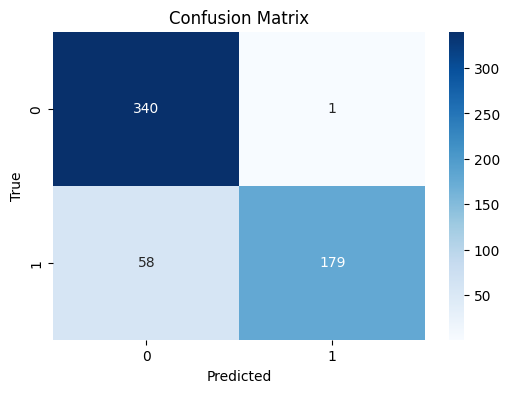

In [99]:
# Print best parameters
print("Best C value:", clf_newton.C_)

# Create a DataFrame for coefficients
coeff_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': clf_newton.coef_[0]})
print("\nFeature Coefficients (all coefficients are used with L2 regularization):")
print(coeff_df.sort_values(by='Coefficient', key=abs, ascending=False))

# Evaluate model performance
y_pred = clf_newton.predict(X_test)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Optional: plot a heatmap of the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [100]:
# Predict on the test set
predictions = clf_newton.predict(test_df)  # This directly outputs 1 or 2

# ----------------------------
# 5. Save the Predictions to a TXT File without a Header
# ----------------------------
output_df = pd.DataFrame({
    'Predicted_Response': predictions
})

# Save as tab-delimited text file without header
output_df.to_csv('predictedL2.txt', sep='\t', index=False, header=False)

print("Final predictions saved to 'predictedL2.txt'.")

Final predictions saved to 'predictedL2.txt'.


# L1

In [101]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Let's assume our dataset is for a regression problem.
# If you're working with a classification task, Elastic Net might be applied within logistic regression.
X = filtered_train_df.drop('response', axis=1)  # Replace 'target' with your target variable
y = filtered_train_df['response']              # Replace 'target' with your target variable

# ----------------------------
# 2. Split the Data
# ----------------------------
# Splitting data into training and testing sets to evaluate the model performance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------
# 2. Scale the Features
# ----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------
# 3. Build the Model using L1 Regularization
# ----------------------------
# Initialize LogisticRegressionCV with L1 penalty using the 'saga' solver
clf_l1 = LogisticRegressionCV(
    Cs=100,
    cv=5,
    penalty='l1',          # Use L1 regularization
    solver='saga',         # 'saga' supports L1 penalty
    max_iter=1000,
    random_state=42,
    scoring='accuracy',
    class_weight= {1:5,2:1}
)

clf_l1.fit(X_train_scaled, y_train)


LogisticRegressionCV(Cs=100, class_weight={1: 5, 2: 1}, cv=5, max_iter=1000,
                     penalty='l1', random_state=42, scoring='accuracy',
                     solver='saga')

Best C value: [138.48863714]

Feature Coefficients (all coefficients are used with L1 regularization):
             Feature  Coefficient
26            george    -9.717730
24                hp    -2.826060
54      capitalTotal     0.910888
45               edu    -0.809528
6             remove     0.728340
49   charExclamation     0.700770
50        charDollar     0.662033
41           meeting    -0.636940
36           num1999    -0.609815
43           project    -0.604329
22            num000     0.600924
4                our     0.599786
34             num85    -0.550266
33            num415     0.535064
52        capitalAve     0.498510
16          business     0.483837
25               hpl    -0.467222
15              free     0.452209
23             money     0.442824
28               lab    -0.436987
27            num650     0.348381
19            credit     0.294347
5               over     0.279024
35        technology     0.274110
44                re    -0.261214
1            

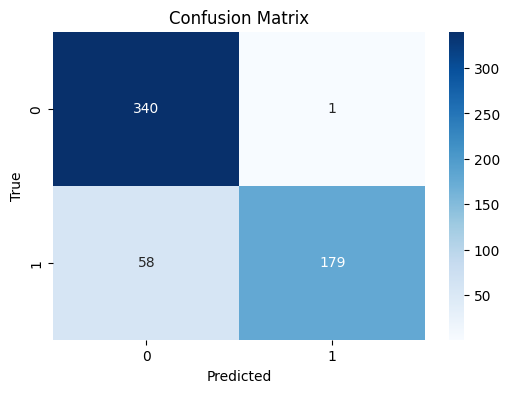

In [102]:
# Print best parameters
print("Best C value:", clf_l1.C_)

# Create a DataFrame for coefficients
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': clf_l1.coef_[0]
})
print("\nFeature Coefficients (all coefficients are used with L1 regularization):")
print(coeff_df.sort_values(by='Coefficient', key=abs, ascending=False))

# Evaluate model performance
y_pred = clf_l1.predict(X_test_scaled)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot a heatmap of the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [103]:
# ----------------------------
# 4. Load Test Data and Generate Predictions
# ----------------------------
test_scaled = scaler.transform(test_df)

# Predict on the test set (predictions will be either 1 or 2)
predictions = clf_l1.predict(test_scaled)

# ----------------------------
# 5. Save the Predictions to a TXT File without a Header
# ----------------------------
output_df = pd.DataFrame({
    'Predicted_Response': predictions
})

# Save as a tab-delimited text file without a header
output_df.to_csv('predictedL1.txt', sep='\t', index=False, header=False)

print("Final predictions saved to 'predictedL1.txt'.")

Final predictions saved to 'predictedL1.txt'.
